C:\Users\ACER\AppData\Local\Temp\ipykernel_36660\3449428039.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


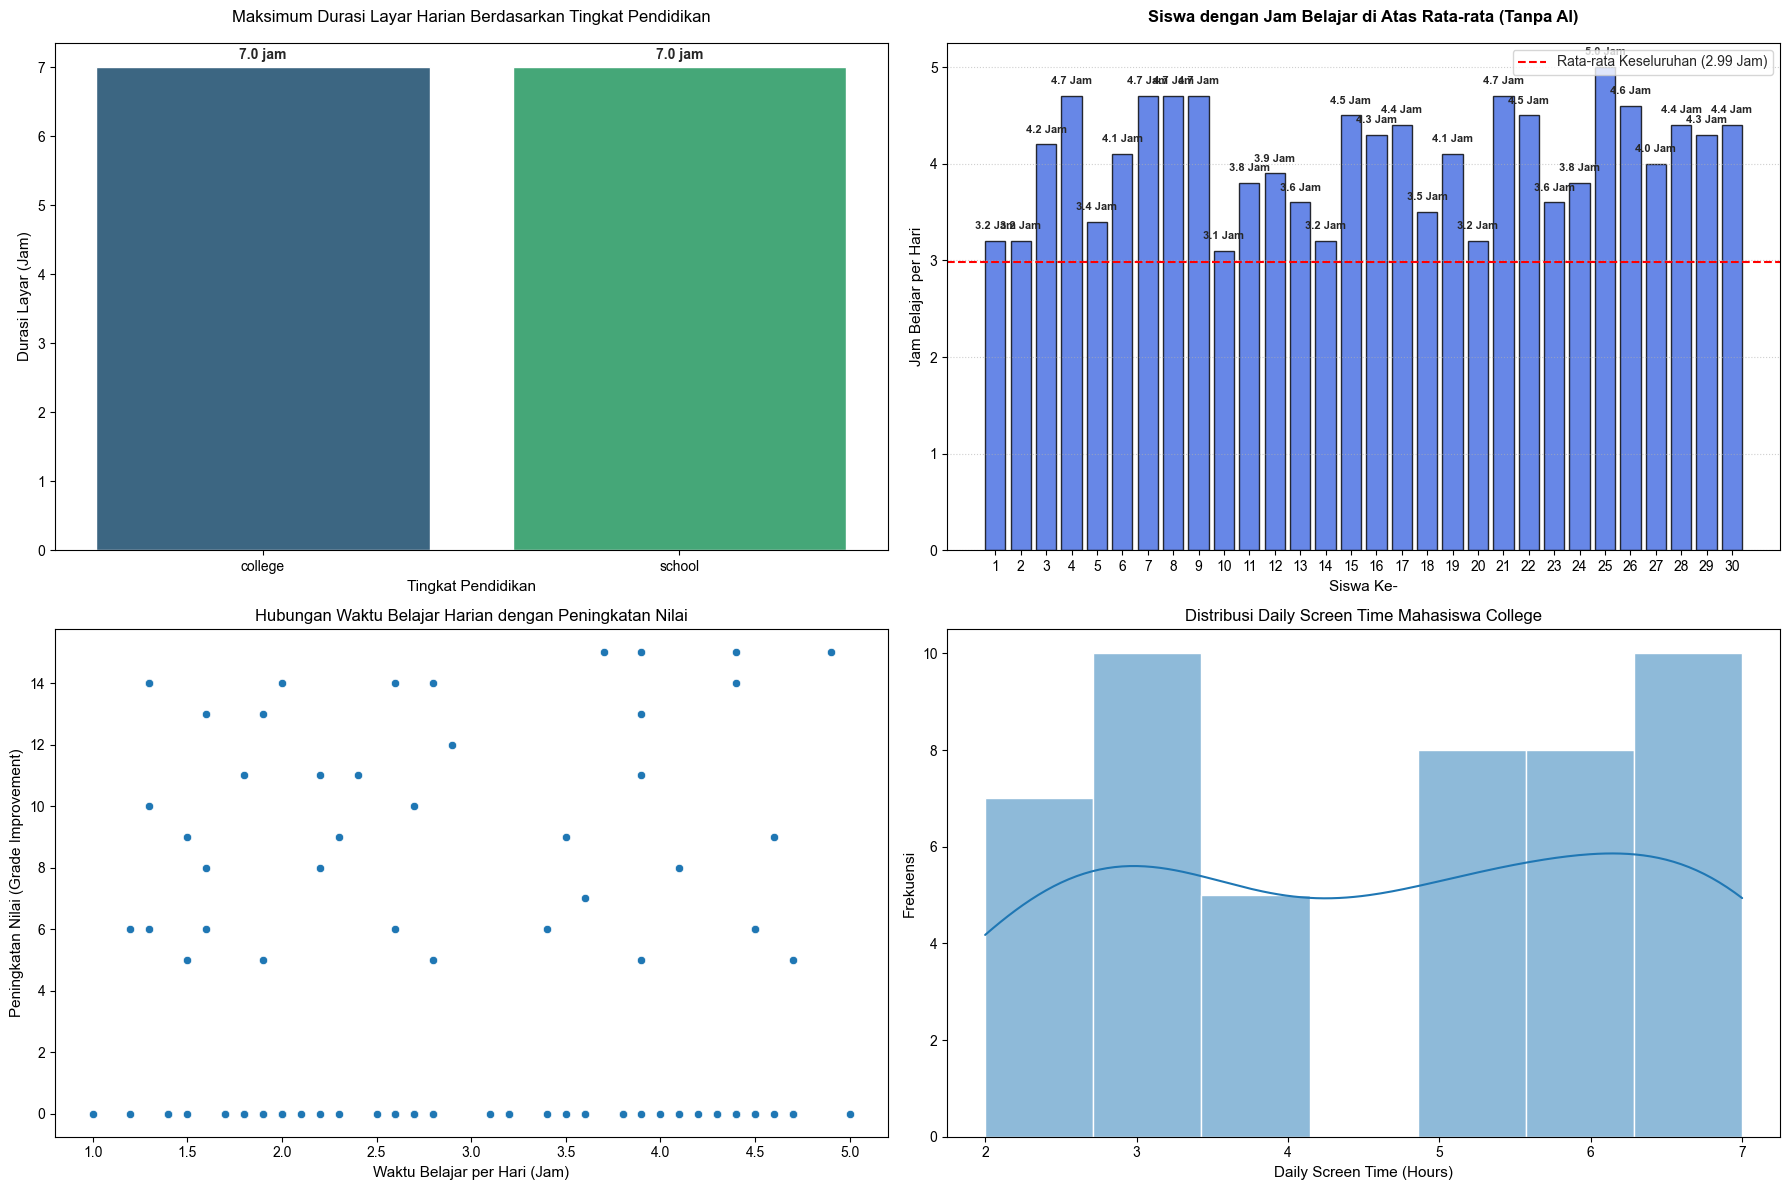

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("Kelas F_Student AI Usage.csv")

# Membuat layout gabungan 4 grafik
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
sns.set_style("whitegrid")

# =====================================================
# Grafik 1 (Kategori A)
# =====================================================
data_grafik = (
    df.groupby("education_level")["daily_screen_time_hours"]
    .max()
    .sort_values(ascending=False)
    .reset_index()
)

ax1 = axes[0, 0]

sns.barplot(
    x="education_level",
    y="daily_screen_time_hours",
    data=data_grafik,
    palette="viridis",
    ax=ax1
)

for p in ax1.patches:
    ax1.annotate(
        f"{p.get_height()} jam",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 9),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold"
    )

ax1.set_title("Maksimum Durasi Layar Harian Berdasarkan Tingkat Pendidikan", fontsize=12, pad=15)
ax1.set_xlabel("Tingkat Pendidikan", fontsize=11)
ax1.set_ylabel("Durasi Layar (Jam)", fontsize=11)

# =====================================================
# Grafik 2 (Kategori B)
# =====================================================
avg_study = df["study_hours_per_day"].mean()

filtered_df = df[
    (df["study_hours_per_day"] > avg_study) &
    (df["uses_ai"] == "No")
].reset_index()

ax2 = axes[0, 1]

bars = ax2.bar(
    filtered_df.index + 1,
    filtered_df["study_hours_per_day"],
    color="royalblue",
    edgecolor="black",
    alpha=0.8
)

ax2.axhline(
    y=avg_study,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"Rata-rata Keseluruhan ({avg_study:.2f} Jam)"
)

for bar in bars:
    yval = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 0.1,
        f"{yval} Jam",
        ha="center",
        va="bottom",
        fontsize=8,
        fontweight="bold"
    )

ax2.set_title("Siswa dengan Jam Belajar di Atas Rata-rata (Tanpa AI)", fontsize=12, fontweight="bold", pad=15)
ax2.set_xlabel("Siswa Ke-", fontsize=11)
ax2.set_ylabel("Jam Belajar per Hari", fontsize=11)
ax2.set_xticks(filtered_df.index + 1)
ax2.grid(axis="y", linestyle=":", alpha=0.6)
ax2.legend(loc="upper right")

# =====================================================
# Grafik 3 (Kategori C)
# =====================================================
df["Grade_Improvement"] = df["grades_after_ai"] - df["grades_before_ai"]

ax3 = axes[1, 0]

sns.scatterplot(
    data=df,
    x="study_hours_per_day",
    y="Grade_Improvement",
    ax=ax3
)

ax3.set_title("Hubungan Waktu Belajar Harian dengan Peningkatan Nilai", fontsize=12)
ax3.set_xlabel("Waktu Belajar per Hari (Jam)", fontsize=11)
ax3.set_ylabel("Peningkatan Nilai (Grade Improvement)", fontsize=11)

# =====================================================
# Grafik 4 (Kategori D)
# =====================================================
college = df[df["education_level"] == "college"]

ax4 = axes[1, 1]

sns.histplot(
    college["daily_screen_time_hours"],
    kde=True,
    ax=ax4
)

ax4.set_title("Distribusi Daily Screen Time Mahasiswa College", fontsize=12)
ax4.set_xlabel("Daily Screen Time (Hours)", fontsize=11)
ax4.set_ylabel("Frekuensi", fontsize=11)

plt.tight_layout()
plt.show()